In [3]:
!pip install --upgrade tensorflow protobuf

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2


Accuracy : 0.9021
Precision: 0.9101
Recall   : 0.7364
F1 Score : 0.8141


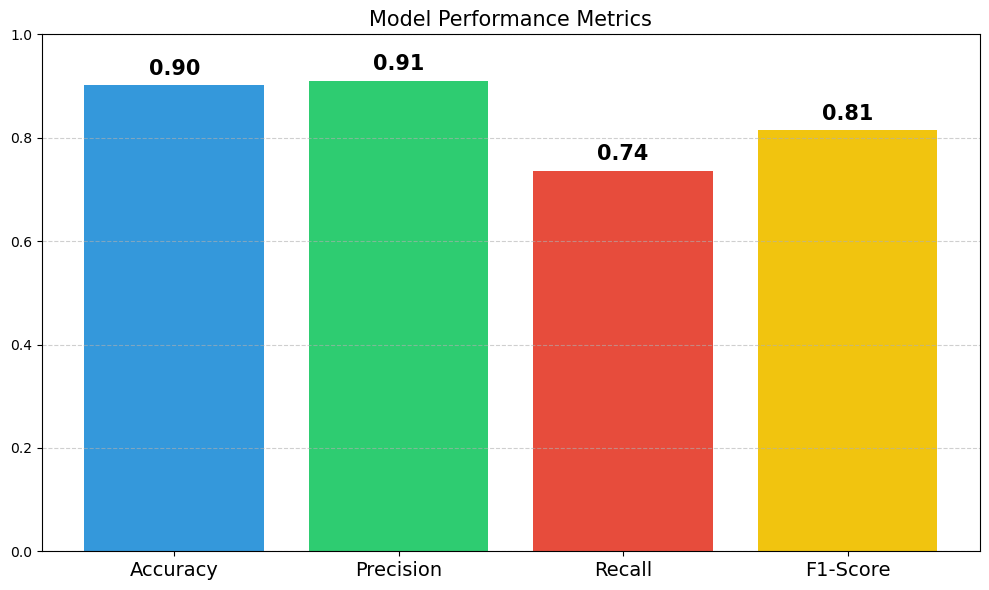

In [5]:
tf.random.set_seed(42)
np.random.seed(42)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # הצגה של שגיאות בלבד

file_path = r"C:\Users\USER\Desktop\לימודים\פרויקט גמר ב\סיוג חשבונות באינסטגרם - מאמר מחקר 1 נועה\איחוד דאטה סט.xlsx"

df = pd.read_excel(file_path)

# הסרנו את Following/Followers
# עמודות מספריות שנדרש לנרמל 
numeric_cols = [
    'numberOfFollowers',
    'numberOfFollowing',
    'nums/length username',
    'descriptionLength',
    'numberOfPosts',
    'Following/Posts',
    'Followers/Posts'
]

feature_order = [
    'numberOfFollowers',
    'numberOfFollowing',
    'nums/length username',
    'hasDigitsInUsername',
    'hasProfilePicture',
    'descriptionLength',
    'isPrivate',
    'numberOfPosts',
    'Following/Posts',
    'Followers/Posts'
]

X = df[feature_order]
y = df['isFake']   # 0 = Real , 1 = Fake

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
#יצירת העתקים של הטבלה כדי לא לעבוד על המקור
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# החלפת הערך בעמודה המספרית בערך המנורמל 
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),

    Dense(1, activation='sigmoid')   # Binary Classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

y_prob = model.predict(X_test_scaled, verbose=0)
y_pred = (y_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc, prec, rec, f1]

plt.figure(figsize=(10,6))

bars = plt.bar(
    metrics,
    values,
    color=['#3498db', '#2ecc71', '#e74c3c', '#f1c40f']
)

plt.title("Model Performance Metrics", fontsize=15)
plt.ylim(0, 1)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center',
        fontsize=15,
        fontweight='bold'
    )

plt.xticks(fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
def predict_instagram_interactive_nn(model, scaler, feature_order, numeric_cols):
    print("\nInstagram Fake Account Detector ***DNN***\n")

    num_followers = float(input("Number of followers: "))
    num_following = float(input("Number of following: "))
    num_posts = float(input("Number of posts: "))
    digit_in_username = float(input("Number of digits in username: "))
    username_length = float(input("Username length: "))
    has_profile_pic_raw = input("Has profile picture? (yes/no): ").strip().lower()
    is_private_raw = input("Is the account private? (yes/no): ").strip().lower()
    description_length = float(input("Bio length (characters): "))

    nums_length_ratio = digit_in_username / username_length if username_length else 0
    has_digit_in_username = 1 if digit_in_username > 0 else 0
    has_profile_pic = 1 if has_profile_pic_raw == "yes" else 0
    is_private = 1 if is_private_raw == "yes" else 0

    # הסרנו את Following/Followers
    following_posts_ratio = num_following / num_posts if num_posts else 0.0
    followers_posts_ratio = num_followers / num_posts if num_posts else 0.0

    user_features = {
        'numberOfFollowers': num_followers,
        'numberOfFollowing': num_following,
        'nums/length username': nums_length_ratio,
        'hasDigitsInUsername': has_digit_in_username,
        'hasProfilePicture': has_profile_pic,
        'descriptionLength': description_length,
        'isPrivate': is_private,
        'numberOfPosts': num_posts,
        'Following/Posts': following_posts_ratio,
        'Followers/Posts': followers_posts_ratio
    }

    input_df = pd.DataFrame([user_features])[feature_order]

    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    prob_fake = model.predict(input_df, verbose=0)[0][0]

    prob_real = 1 - prob_fake

    print("\n--- Class probabilities ---")
    print(f"REAL (0): {prob_real*100:.2f}%")
    print(f"FAKE (1): {prob_fake*100:.2f}%")

    prediction = 1 if prob_fake > 0.5 else 0
    confidence = prob_fake*100 if prediction == 1 else (1-prob_fake)*100
    label = "FAKE" if prediction == 1 else "REAL"

    print("\n==============================")
    print(f"Prediction Result: {label}")
    print(f"Confidence Level: {confidence:.2f}%")
    print("==============================")

    return prediction, confidence


predict_instagram_interactive_nn(model, scaler, feature_order, numeric_cols)


Instagram Fake Account Detector ***DNN***



Number of followers:  92700
Number of following:  3580
Number of posts:  768
Number of digits in username:  0
Username length:  10
Has profile picture? (yes/no):  yes
Is the account private? (yes/no):  yes
Bio length (characters):  40



--- Class probabilities ---
REAL (0): 99.33%
FAKE (1): 0.67%

Prediction Result: REAL
Confidence Level: 99.33%


(0, np.float32(99.32525))